
===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====
User inputs loaded.
Analysis folder: G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis

NI continuous (absolute): 12.975025 → 2460.251200 s
NP continuous (absolute): 12.782467 → 2460.071833 s

Canonical t0 = NP stream start = 12.782467 s (absolute)
NI stream starts +0.192558 s relative to t0

===== NP ↔ NI SYNC ALIGNMENT =====
NI TTL folder: G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL
NP TTL folder: G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\events\Neuropix-PXI-100.ProbeA\TTL
NI sync pulses (bit 5): 2447
NP sync pulses (bit 0): 2448

Linear fit: t_NI = 1.000000766 * t_NP + 1.159901802
Residuals  mean=0.0000 ms  std=0.0357 ms  max=0.0897 ms

Saved alignment metadata.

Recording duration (canonical): 2447.289 s

===== SPIKE TIME ANCHOR DIAGNOSTIC =====
NI stream offset from NP start: +0.192558 s


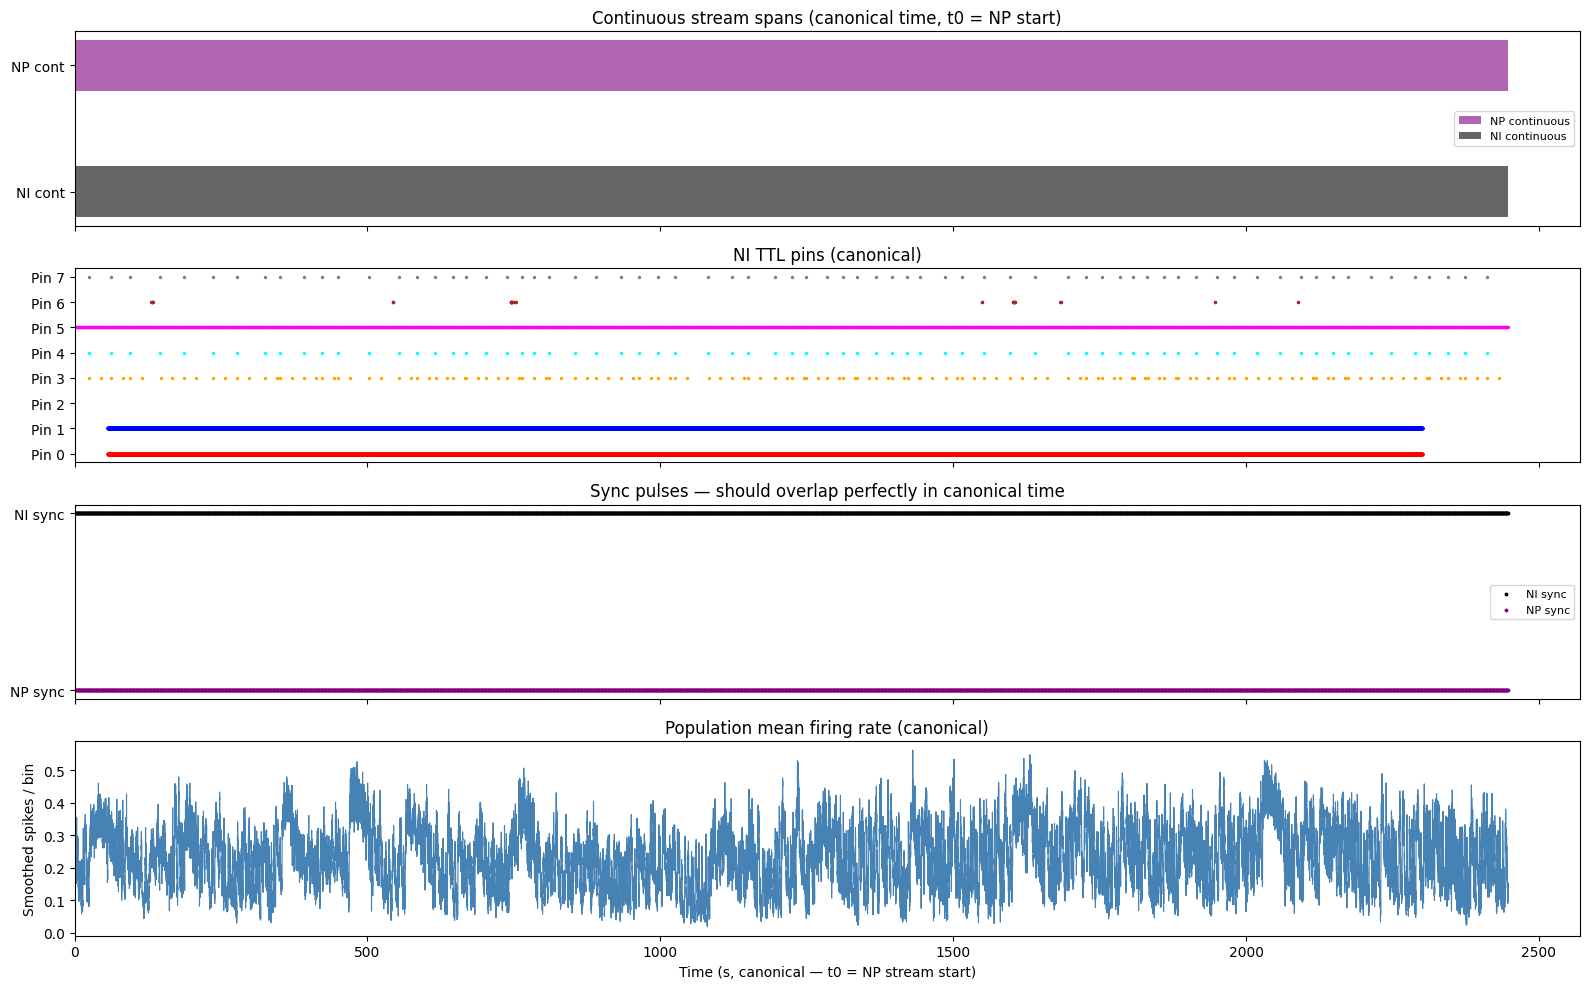

===== CELL A COMPLETE =====



In [3]:
# ============================================================
# =======================  CELL A  ============================
# ========== ROOT CELL — TTLs + QC + PORTABLE SPIKES =========
# ========== WITH NP ↔ NI CLOCK ALIGNMENT (SYNC) =============
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

print("\n===== CELL A — ROOT PORTABLE EXTRACTION + NP↔NI ALIGNMENT =====")

# ------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------

SESSION_FOLDER = r"D:\Kevin\04032026"

NI_TTL_FOLDER = r"G:\Kevin\2026-03-04_08-31-33\Record Node 104\experiment1\recording1\events\NI-DAQmx-103.PXIe-6341\TTL"
PROBEA_PATH   = r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

EXPERIMENT_NUMBER = 1

CAMERA_TTL_PIN = 1
EXPECTED_RATE_HZ = 60
MISSING_TTL_THRESHOLD = 60
MIN_BLOCK_LENGTH = 500

FILENAME_PATTERN = r"frame_(\d+)_cnt_(\d+)\.raw"

NI_SYNC_BIT = 5
NP_SYNC_BIT = 0

NP_SAMPLE_RATE = 30000.0

print("User inputs loaded.")

# ------------------------------------------------------------
# UNIFIED ANALYSIS FOLDER
# ------------------------------------------------------------

def find_session_root(path):
    path = Path(path).resolve()
    while True:
        if "record node" in path.name.lower():
            return path
        parent = path.parent
        if parent == path:
            raise RuntimeError("Could not find 'Record Node' folder above given path")
        path = parent

def build_analysis_folder(session_root, experiment_number):
    experiment_folders = sorted(
        [f for f in session_root.iterdir()
         if f.is_dir() and f.name.lower().startswith("experiment")],
        key=lambda p: p.name
    )
    if experiment_number < 1 or experiment_number > len(experiment_folders):
        raise RuntimeError(f"Experiment {experiment_number} not found.")
    experiment_folder = experiment_folders[experiment_number - 1]
    recording_folders = sorted(
        [f for f in experiment_folder.iterdir()
         if f.is_dir() and f.name.lower().startswith("recording")],
        key=lambda p: p.name
    )
    if not recording_folders:
        raise RuntimeError("No recording folder found.")
    recording_folder = recording_folders[0]
    session_date = session_root.parent.name
    folder_name = f"{session_date}_{experiment_folder.name}_{recording_folder.name}_analysis"
    analysis_folder = session_root / folder_name
    analysis_folder.mkdir(exist_ok=True)
    for sf in ["qc","camera_alignment","dlc_alignment","behavior_ttls",
               "peak_detection","metadata","ttls","spikes"]:
        (analysis_folder / sf).mkdir(exist_ok=True)
    print(f"Analysis folder: {analysis_folder}")
    return analysis_folder

analysis_folder = build_analysis_folder(
    find_session_root(PROBEA_PATH), EXPERIMENT_NUMBER
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def save_incrementing(folder, base_name, array):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    path = folder / f"{base_name}.npy"
    if not path.exists():
        np.save(path, array)
        return path
    counter = 1
    while True:
        path = folder / f"{base_name}_{counter}.npy"
        if not path.exists():
            np.save(path, array)
            return path
        counter += 1

def extract_rising_edges(full_words, timestamps, pin):
    mask = 1 << pin
    bit_on = (full_words & mask) > 0
    bit_prev = np.roll(bit_on, 1)
    bit_prev[0] = False
    rising = (~bit_prev) & bit_on
    return timestamps[rising]

# ------------------------------------------------------------
# LOAD CONTINUOUS TIMESTAMPS
# ------------------------------------------------------------

ni_ttl_folder    = Path(NI_TTL_FOLDER)
ni_device_name   = ni_ttl_folder.parent.name            # NI-DAQmx-106.PXIe-6341
recording_root   = ni_ttl_folder.parents[2]             # .../experiment2/recording1
ni_cont_folder   = recording_root / "continuous" / ni_device_name
probe_cont_folder = Path(PROBEA_PATH).parent            # .../Neuropix-PXI-107.ProbeA

ni_cont_timestamps = np.load(ni_cont_folder   / "timestamps.npy")
np_cont_timestamps = np.load(probe_cont_folder / "timestamps.npy")

ni_start_abs = float(ni_cont_timestamps[0])
ni_end_abs   = float(ni_cont_timestamps[-1])
np_start_abs = float(np_cont_timestamps[0])
np_end_abs   = float(np_cont_timestamps[-1])

print(f"\nNI continuous (absolute): {ni_start_abs:.6f} → {ni_end_abs:.6f} s")
print(f"NP continuous (absolute): {np_start_abs:.6f} → {np_end_abs:.6f} s")

# ============================================================
# CANONICAL TIMEBASE DECISION
# ============================================================
# We use the NP continuous start as t0 (our ground truth).
# Everything — spikes, TTLs, DLC — will be expressed as seconds
# elapsed since the NP recording began.
#
# Why NP and not NI?
#   - Kilosort spike_times.npy is in NP samples from NP stream start.
#   - The NP stream is always the longest / most complete signal.
#   - All other signals get mapped into this frame.
# ============================================================

t0 = np_start_abs   # canonical zero = NP stream start (absolute clock)

print(f"\nCanonical t0 = NP stream start = {t0:.6f} s (absolute)")
print(f"NI stream starts {ni_start_abs - t0:+.6f} s relative to t0")
# Positive → NI started after NP (common if NP armed first)

# ------------------------------------------------------------
# SYNC PULSE ALIGNMENT: verify NP↔NI are on same clock
# ------------------------------------------------------------

print("\n===== NP ↔ NI SYNC ALIGNMENT =====")

timestamps_ni_ttl = np.load(ni_ttl_folder / "timestamps.npy")
full_words_ni     = np.load(ni_ttl_folder / "full_words.npy")

# Derive NP TTL folder from PROBEA_PATH, not hardcoded.
np_device_name    = probe_cont_folder.name                # Neuropix-PXI-XXX.ProbeA
np_recording_root = probe_cont_folder.parents[1]          # .../experimentN/recording1
np_ttl_folder     = np_recording_root / "events" / np_device_name / "TTL"

print(f"NI TTL folder: {ni_ttl_folder}")
print(f"NP TTL folder: {np_ttl_folder}")

if not np_ttl_folder.exists():
    raise FileNotFoundError(
        f"NP TTL folder not found:\n  {np_ttl_folder}\n"
        f"Check that PROBEA_PATH points to the correct kilosort4 folder."
    )

timestamps_np_ttl = np.load(np_ttl_folder / "timestamps.npy")
full_words_np     = np.load(np_ttl_folder / "full_words.npy")

sync_times_ni_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, NI_SYNC_BIT)
sync_times_np_abs = extract_rising_edges(full_words_np, timestamps_np_ttl, NP_SYNC_BIT)

print(f"NI sync pulses (bit {NI_SYNC_BIT}): {len(sync_times_ni_abs)}")
print(f"NP sync pulses (bit {NP_SYNC_BIT}): {len(sync_times_np_abs)}")

if len(sync_times_ni_abs) == 0:
    raise RuntimeError("No NI sync pulses found.")
if len(sync_times_np_abs) == 0:
    raise RuntimeError("No NP sync pulses found.")

n_common = min(len(sync_times_np_abs), len(sync_times_ni_abs))
sync_np  = sync_times_np_abs[:n_common]
sync_ni  = sync_times_ni_abs[:n_common]

A_mat = np.vstack([sync_np, np.ones_like(sync_np)]).T
a_fit, b_fit = np.linalg.lstsq(A_mat, sync_ni, rcond=None)[0]
residuals = sync_ni - (a_fit * sync_np + b_fit)

print(f"\nLinear fit: t_NI = {a_fit:.9f} * t_NP + {b_fit:.9f}")
print(f"Residuals  mean={np.mean(residuals)*1000:.4f} ms  "
      f"std={np.std(residuals)*1000:.4f} ms  "
      f"max={np.max(np.abs(residuals))*1000:.4f} ms")

# With a≈1 and b≈0 (same clock), the fit confirms the two streams share
# the OpenEphys master clock.  We still apply it for correctness in case
# there is any tiny drift.

# Save alignment metadata
align_meta = {
    "np_to_ni_a": float(a_fit),
    "np_to_ni_b": float(b_fit),
    "n_pulses": int(n_common),
    "residual_mean_s": float(np.mean(residuals)),
    "residual_std_s":  float(np.std(residuals)),
    "residual_max_abs_s": float(np.max(np.abs(residuals))),
    "ni_sync_bit": int(NI_SYNC_BIT),
    "np_sync_bit": int(NP_SYNC_BIT),
    "t0_abs": float(t0),
    "ni_start_abs": float(ni_start_abs),
    "np_start_abs": float(np_start_abs),
    "ni_start_rel": float(ni_start_abs - t0),
    "ni_end_rel":   float(ni_end_abs   - t0),
    "np_start_rel": 0.0,
    "np_end_rel":   float(np_end_abs   - t0),
}
with open(analysis_folder / "metadata" / "np_ni_alignment.json", "w") as f:
    json.dump(align_meta, f, indent=2)
print(f"\nSaved alignment metadata.")

# ============================================================
# UNIFIED CONVERSION FUNCTIONS
# ============================================================
# All downstream code should use these — never subtract t0 manually.

def np_samples_to_canonical(samples):
    """Kilosort spike_times (NP samples) → canonical seconds."""
    # samples / sample_rate  → seconds from NP stream start (already = t0)
    # No further offset needed because t0 IS np_start_abs and
    # OpenEphys sample indices start at the stream start.
    return samples / NP_SAMPLE_RATE

def np_abs_to_canonical(t_np_abs):
    """NP absolute time → canonical seconds."""
    return t_np_abs - t0

def ni_abs_to_canonical(t_ni_abs):
    """NI absolute time → canonical seconds."""
    return t_ni_abs - t0

# Canonical duration = full NP recording
recording_duration = float(np_end_abs - t0)
print(f"\nRecording duration (canonical): {recording_duration:.3f} s")

# ============================================================
# CRITICAL DIAGNOSTIC: verify spike time anchor
# ============================================================
# Load spike_times.npy and check that the first and last spikes
# fall within [0, recording_duration].  If they fall within
# [-ni_start_rel, recording_duration - ni_start_rel] instead,
# that means Kilosort spike_times are in NI-absolute samples,
# and you need to subtract the NP stream start offset.
# ============================================================

spike_times_raw = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
spike_times_sec_raw = spike_times_raw / NP_SAMPLE_RATE

ni_start_rel = ni_start_abs - t0   # typically a small positive number

print(f"\n===== SPIKE TIME ANCHOR DIAGNOSTIC =====")
print(f"NI stream offset from NP start: {ni_start_rel:+.6f} s")
print(f"First 5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[:5]}")
print(f"Last  5 spike times (raw, seconds from sample 0): "
      f"{spike_times_sec_raw[-5:]}")
print(f"Expected canonical range: 0 → {recording_duration:.3f} s")
print(f"If spikes appear in range {-ni_start_rel:.3f} → "
      f"{recording_duration - ni_start_rel:.3f} s")
print(f"  → spike_times are anchored to NI start, not NP start.")
print(f"  → You need: spike_canonical = spikes_sec - {ni_start_rel:.6f}")
print(f"If spikes appear in range 0 → {recording_duration:.3f} s")
print(f"  → spike_times are anchored to NP start (correct, no adjustment).")

# Auto-detect anchor and apply correct conversion
spike_min = float(spike_times_sec_raw.min())
spike_max = float(spike_times_sec_raw.max())

if abs(spike_min) < 5.0 and spike_max <= recording_duration + 5.0:
    print("\n→ AUTO-DETECTED: spikes anchored to NP start. No offset needed.")
    spike_anchor_offset = 0.0
elif abs(spike_min - ni_start_rel) < 5.0:
    print(f"\n→ AUTO-DETECTED: spikes anchored to NI start. "
          f"Applying offset of -{ni_start_rel:.6f} s.")
    spike_anchor_offset = ni_start_rel
else:
    print(f"\n→ WARNING: spike anchor unclear. "
          f"spike_min={spike_min:.3f}, ni_start_rel={ni_start_rel:.6f}. "
          f"Defaulting to 0 offset — PLEASE VERIFY MANUALLY.")
    spike_anchor_offset = 0.0

print(f"spike_anchor_offset = {spike_anchor_offset:.6f} s")

def spikes_to_canonical(spike_samples):
    """Full pipeline: NP samples → canonical seconds."""
    return spike_samples / NP_SAMPLE_RATE - spike_anchor_offset

# ============================================================
# NI TTL EXTRACTION → canonical time
# ============================================================

print("\n===== EXTRACTING NI TTLs → CANONICAL TIME =====")

ttls_dir = analysis_folder / "ttls"
all_pin_ttls = {}   # canonical seconds

for pin in range(8):
    ttls_abs = extract_rising_edges(full_words_ni, timestamps_ni_ttl, pin)
    ttls_can = ni_abs_to_canonical(ttls_abs)
    all_pin_ttls[pin] = ttls_can
    save_incrementing(ttls_dir, f"TTL_Pin_{pin}", ttls_can)
    print(f"  Pin {pin}: {len(ttls_can)} TTLs", end="")
    if len(ttls_can):
        print(f"  range {ttls_can[0]:.3f} → {ttls_can[-1]:.3f} s")
    else:
        print()

ni_meta = {
    "canonical_t0_is": "NP stream start (np_start_abs)",
    "t0_abs": float(t0),
    "ni_start_canonical": float(ni_start_abs - t0),
    "ni_end_canonical":   float(ni_end_abs   - t0),
    "np_start_canonical": 0.0,
    "np_end_canonical":   float(np_end_abs   - t0),
    "recording_duration": float(recording_duration),
    "camera_ttl_pin": int(CAMERA_TTL_PIN),
    "expected_rate_hz": EXPECTED_RATE_HZ,
    "spike_anchor_offset_s": float(spike_anchor_offset),
}
with open(analysis_folder / "metadata" / "ttl_metadata.json", "w") as f:
    json.dump(ni_meta, f, indent=2)
print("Saved TTL metadata.")

# ============================================================
# TTL BLOCK DETECTION
# ============================================================

print("\n===== TTL BLOCK DETECTOR =====")

rising_times = all_pin_ttls[CAMERA_TTL_PIN]
print(f"Camera pin {CAMERA_TTL_PIN}: {len(rising_times)} rising edges")

ipi           = np.diff(rising_times)
expected_ipi  = 1.0 / EXPECTED_RATE_HZ
gap_threshold = expected_ipi * MISSING_TTL_THRESHOLD
gap_indices   = np.where(ipi > gap_threshold)[0]

block_starts = np.insert(gap_indices + 1, 0, 0)
block_ends   = np.append(gap_indices, len(rising_times) - 1)

ttl_blocks = []
block_info = []
cam_align_dir = analysis_folder / "camera_alignment"

for b_idx, (start, end) in enumerate(zip(block_starts, block_ends)):
    block_len = end - start + 1
    if block_len < MIN_BLOCK_LENGTH:
        print(f"  Skipping block {b_idx} (too short: {block_len})")
        continue
    block_times = rising_times[start:end+1]
    ttl_blocks.append(block_times)
    info = {
        "block_index": b_idx,
        "n_ttls": int(block_len),
        "start_canonical": float(block_times[0]),
        "end_canonical":   float(block_times[-1]),
        "duration_s":      float(block_times[-1] - block_times[0]),
    }
    block_info.append(info)
    save_incrementing(cam_align_dir, f"ttl_times_block{b_idx}", block_times)
    print(f"  Block {b_idx}: {block_len} TTLs, "
          f"{block_times[0]:.3f} → {block_times[-1]:.3f} s (canonical)")

with open(analysis_folder / "metadata" / "block_info.json", "w") as f:
    json.dump(block_info, f, indent=2)

# ============================================================
# QC: FIRING-RATE MATRIX
# ============================================================

print("\n===== QC: FIRING-RATE MATRIX =====")

qc_dir        = analysis_folder / "qc"
spikes_dir    = analysis_folder / "spikes"

rate_path          = qc_dir / "rate_matrix.npy"
good_units_path    = qc_dir / "good_units.npy"
centers_path       = qc_dir / "centers.npy"
duration_path      = qc_dir / "recording_duration.json"
noise_units_path   = qc_dir / "noise_units.npy"
noise_rate_path    = qc_dir / "noise_rate_matrix.npy"
spike_anchor_path  = qc_dir / "spike_anchor_offset.json"

all_qc_exist = all(p.exists() for p in [
    rate_path, good_units_path, centers_path, duration_path,
    noise_units_path, noise_rate_path
])

if all_qc_exist:
    print("QC files already exist — skipping.")
else:
    print("Computing QC...")

    spike_times_raw  = np.load(Path(PROBEA_PATH) / "spike_times.npy").flatten()
    spike_clusters   = np.load(Path(PROBEA_PATH) / "spike_clusters.npy").flatten()
    spike_times_can  = spikes_to_canonical(spike_times_raw)  # canonical seconds

    print(f"Spike time canonical range: "
          f"{spike_times_can.min():.3f} → {spike_times_can.max():.3f} s")
    print(f"Recording duration:          0.000 → {recording_duration:.3f} s")

    if spike_times_can.max() < recording_duration * 0.9:
        print("WARNING: spikes end well before recording end — "
              "check spike_anchor_offset!")
    if spike_times_can.min() < -1.0:
        print("WARNING: spikes start before t=0 — check spike_anchor_offset!")

    df_info    = pd.read_csv(Path(PROBEA_PATH) / "cluster_info.tsv", sep="\t")
    good_units = df_info[df_info["group"] == "good"]["id"].values
    np.save(good_units_path, good_units)
    print(f"Good units: {len(good_units)}")

    for unit in good_units:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"unit_{unit}.npy", unit_spikes)

# Sample noise units matched to the number of good units
# (so downstream noise-vs-real comparisons have equal sample sizes)
    noise_units_all = df_info[df_info["group"] == "noise"]["id"].values
    print(f"Total noise units available: {len(noise_units_all)}")

# Filter noise units by minimum firing rate, same way good units would be
# filtered downstream. This ensures the noise pool we sample from is
# comparable in firing-rate distribution to the good pool.
    noise_rates = np.array([
        (spike_clusters == u).sum() / recording_duration
        for u in noise_units_all
    ])
    NOISE_MIN_RATE_HZ = 0.5  # matches a permissive floor; tightened downstream
    eligible_noise = noise_units_all[noise_rates >= NOISE_MIN_RATE_HZ]
    print(f"Noise units with ≥{NOISE_MIN_RATE_HZ} Hz: {len(eligible_noise)}")

# Sample N_target noise units matched to good unit count
    N_target = len(good_units)
    np.random.seed(0)
    if len(eligible_noise) >= N_target:
        sampled_noise = np.random.choice(eligible_noise, size=N_target, replace=False)
        print(f"Sampled {N_target} noise units (matched to good unit count).")
    else:
        sampled_noise = eligible_noise
        print(f"WARNING: only {len(eligible_noise)} eligible noise units available "
              f"(wanted {N_target}). Using all available.")

    np.save(noise_units_path, sampled_noise)

    for unit in sampled_noise:
        unit_spikes = spike_times_can[spike_clusters == unit]
        np.save(spikes_dir / f"noise_unit_{unit}.npy", unit_spikes)
    print(f"Saved {len(sampled_noise)} noise unit spike trains to disk.")

    # Save spike anchor for downstream cells
    with open(spike_anchor_path, "w") as f:
        json.dump({"spike_anchor_offset_s": float(spike_anchor_offset),
                   "t0_abs": float(t0)}, f, indent=2)

    # Time bins over full NP recording
    bin_size = 0.02
    bins    = np.arange(0, recording_duration + bin_size, bin_size)
    centers = bins[:-1] + bin_size / 2
    np.save(centers_path, centers)
    with open(duration_path, "w") as f:
        json.dump({"recording_duration": recording_duration,
                   "t0_abs": float(t0)}, f, indent=2)

    # Rate matrices
    def make_rate_matrix(unit_list, label):
        mat = np.zeros((len(unit_list), len(centers)), float)
        for i, unit in enumerate(unit_list):
            spk = spike_times_can[spike_clusters == unit]
            h, _ = np.histogram(spk, bins=bins)
            mat[i] = gaussian_filter1d(h.astype(float), sigma=2)
        return mat

    rate_matrix       = make_rate_matrix(good_units,   "good")
    noise_rate_matrix = make_rate_matrix(sampled_noise,"noise")
    np.save(rate_path,       rate_matrix)
    np.save(noise_rate_path, noise_rate_matrix)
    print(f"Saved rate_matrix {rate_matrix.shape}")
    print(f"Saved noise_rate_matrix {noise_rate_matrix.shape}")

# ============================================================
# DIAGNOSTIC PLOT — canonical timeline
# ============================================================

print("\n===== CANONICAL TIMELINE DIAGNOSTIC =====")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Row 0: NP and NI continuous spans
for ax in axes[:1]:
    ax.barh(1, recording_duration,       left=0,
            height=0.4, color='purple', alpha=0.6, label="NP continuous")
    ax.barh(0, ni_end_abs - t0,          left=ni_start_abs - t0,
            height=0.4, color='black',  alpha=0.6, label="NI continuous")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["NI cont", "NP cont"])
    ax.legend(fontsize=8)
    ax.set_title("Continuous stream spans (canonical time, t0 = NP start)")

# Row 1: TTL pins
colors8 = ['red','blue','green','orange','cyan','magenta','brown','gray']
ax1 = axes[1]
for pin in range(8):
    tt = all_pin_ttls[pin]
    ax1.scatter(tt, np.full_like(tt, pin), s=2, color=colors8[pin],
                label=f"Pin {pin}")
ax1.set_yticks(range(8))
ax1.set_yticklabels([f"Pin {p}" for p in range(8)])
ax1.set_title("NI TTL pins (canonical)")

# Row 2: sync pulses overlap check
ax2 = axes[2]
sync_ni_can  = ni_abs_to_canonical(sync_times_ni_abs)
sync_np_can  = np_abs_to_canonical(sync_times_np_abs)
ax2.scatter(sync_ni_can, np.ones_like(sync_ni_can)*1,
            s=3, color='black', label="NI sync")
ax2.scatter(sync_np_can, np.ones_like(sync_np_can)*0,
            s=3, color='purple', label="NP sync")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NP sync","NI sync"])
ax2.set_title("Sync pulses — should overlap perfectly in canonical time")
ax2.legend(fontsize=8)

# Row 3: spike density
ax3 = axes[3]
if centers_path.exists():
    centers_saved = np.load(centers_path)
    rm = np.load(rate_path)
    ax3.plot(centers_saved, rm.mean(axis=0), color='steelblue', lw=0.8)
    ax3.set_title("Population mean firing rate (canonical)")
    ax3.set_ylabel("Smoothed spikes / bin")

axes[-1].set_xlabel("Time (s, canonical — t0 = NP stream start)")
plt.tight_layout()
plt.show()

print("===== CELL A COMPLETE =====\n")

In [4]:
# ============================================================
# CELL B — FRAME ALIGNMENT (RIG-ONLY) — CORRECTED
# ============================================================
# Camera behavior assumed (confirmed by Kevin):
#   - frame_idx resets to 0 each block; contiguous (no gaps)
#   - first saved frame == TTL #0 of the block
#   - cnt is a free-running counter (offset is arbitrary).
#     Drops show up as gaps in cnt.
#
# Mapping: saved frame at position p
#          → ttl_index_in_block = cnt[p] - cnt[0]
#          → canonical_time     = ttl_times_block[cnt[p] - cnt[0]]
# ============================================================
import os, re, json
import numpy as np
from pathlib import Path

print("\n===== CELL B — FRAME ALIGNMENT (RIG) =====")

required_vars = ["analysis_folder", "ttl_blocks", "FILENAME_PATTERN"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"'{v}' missing — run Cell A first.")

# ------------------------------------------------------------
# USER EDIT — camera folder per block
# ------------------------------------------------------------
CAM_FOLDERS = {
    0: r"D:\Kevin\04032026\04032026-1\cam2"
}
# ------------------------------------------------------------

if len(CAM_FOLDERS) != len(ttl_blocks):
    raise ValueError(f"CAM_FOLDERS has {len(CAM_FOLDERS)} entries "
                     f"but there are {len(ttl_blocks)} TTL blocks.")
if set(CAM_FOLDERS.keys()) != set(range(len(ttl_blocks))):
    raise ValueError(f"CAM_FOLDERS keys must be {set(range(len(ttl_blocks)))}.")
for b, p in CAM_FOLDERS.items():
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Camera folder for block {b} missing: {p}")

PATTERN = re.compile(FILENAME_PATTERN)
cam_align_dir = analysis_folder / "camera_alignment"
cam_align_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# PROCESS EACH BLOCK
# ------------------------------------------------------------
for block_index, ttl_times_block in enumerate(ttl_blocks):

    print(f"\n--- Block {block_index} ---")
    cam_folder = CAM_FOLDERS[block_index]
    n_ttls = len(ttl_times_block)
    print(f"TTLs in block: {n_ttls}")
    print(f"Camera folder: {cam_folder}")

    # Scan filenames
    entries = []
    for fname in os.listdir(cam_folder):
        m = PATTERN.match(fname)
        if m:
            entries.append((int(m.group(1)), int(m.group(2)), fname))
    if not entries:
        raise RuntimeError(f"No matching files in {cam_folder}")

    entries.sort(key=lambda e: e[1])  # sort by cnt
    frame_idx_arr = np.array([e[0] for e in entries], dtype=np.int64)
    cnt_arr       = np.array([e[1] for e in entries], dtype=np.int64)

    n_saved   = len(entries)
    first_cnt = int(cnt_arr[0])
    last_cnt  = int(cnt_arr[-1])
    cnt_span  = last_cnt - first_cnt + 1   # TTLs covered by camera save window

    print(f"Saved frames: {n_saved}")
    print(f"frame_idx range: {int(frame_idx_arr[0])} → {int(frame_idx_arr[-1])}")
    print(f"cnt range: {first_cnt} → {last_cnt}")
    print(f"cnt span (TTLs covered by camera): {cnt_span}")
    print(f"Implied drops within camera window: {cnt_span - n_saved}")

    # ----- Invariant 1: first frame_idx must be 0 -----
    if int(frame_idx_arr[0]) != 0:
        raise RuntimeError(
            f"Block {block_index}: first saved frame has frame_idx="
            f"{int(frame_idx_arr[0])}, expected 0. Camera should reset "
            f"frame_idx to 0 at block start."
        )

    # ----- Invariant 2: frame_idx contiguous (no gaps) -----
    fidx_gaps = np.where(np.diff(frame_idx_arr) != 1)[0]
    if len(fidx_gaps) > 0:
        raise RuntimeError(
            f"Block {block_index}: frame_idx has gaps at positions "
            f"{fidx_gaps[:5].tolist()}{'...' if len(fidx_gaps) > 5 else ''}. "
            f"frame_idx should be contiguous; drops live in cnt only."
        )

    # ----- Invariant 3: cnt span fits within TTL block -----
    # The camera can stop saving before the last TTL (trailing TTLs are
    # benign). It must NOT extend past the TTL block.
    if cnt_span > n_ttls:
        raise RuntimeError(
            f"Block {block_index}: cnt span ({cnt_span}) exceeds TTL count "
            f"({n_ttls}). The camera appears to have received more TTLs "
            f"than the TTL detector found, which means the block "
            f"boundaries are wrong."
        )

    # ----- Invariant 4: how much TTL hangs off the end? Report it. -----
    trailing_ttls = n_ttls - cnt_span
    trailing_secs = (ttl_times_block[-1] - ttl_times_block[cnt_span - 1]
                     if cnt_span > 0 else 0.0)
    print(f"Trailing TTLs after camera stopped: {trailing_ttls} "
          f"(~{trailing_secs:.2f} s)")
    if trailing_ttls > n_ttls * 0.1:
        print(f"  WARNING: more than 10% of TTLs are trailing. "
              f"Check that you didn't stop the camera way before "
              f"stopping OpenEphys.")

    # ------------------------------------------------------------
    # CORE MAPPING
    # ------------------------------------------------------------
    # For each saved frame, compute its TTL index in the block
    # and look up the canonical time.
    # ------------------------------------------------------------
    ttl_idx_in_block = cnt_arr - first_cnt          # shape (n_saved,)
    frame_canonical_times = ttl_times_block[ttl_idx_in_block]

    # Sanity: monotonic increasing
    if not np.all(np.diff(frame_canonical_times) > 0):
        raise RuntimeError(
            f"Block {block_index}: frame canonical times are not strictly "
            f"increasing. This indicates a sorting or cnt error."
        )

    # ------------------------------------------------------------
    # SAVE PORTABLE ARRAYS
    # ------------------------------------------------------------
    np.save(cam_align_dir / f"frame_cnt_block{block_index}.npy", cnt_arr)
    np.save(cam_align_dir / f"frame_canonical_times_block{block_index}.npy",
            frame_canonical_times)

    print(f"Wrote frame_cnt_block{block_index}.npy "
          f"and frame_canonical_times_block{block_index}.npy")
    print(f"Frame canonical time range: "
          f"{frame_canonical_times[0]:.3f} → {frame_canonical_times[-1]:.3f} s")

# ------------------------------------------------------------
# Save frame-alignment metadata
# ------------------------------------------------------------
frame_meta = {
    str(b): {
        "cam_folder": CAM_FOLDERS[b],
        "n_saved_frames": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy").size),
        "n_ttls": int(len(ttl_blocks[b])),
        "first_cnt": int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[0]),
        "last_cnt":  int(np.load(cam_align_dir / f"frame_cnt_block{b}.npy")[-1]),
    }
    for b in range(len(ttl_blocks))
}
with open(analysis_folder / "metadata" / "frame_alignment.json", "w") as f:
    json.dump(frame_meta, f, indent=2)

print("\n===== CELL B COMPLETE — RIG WORK DONE =====")
print("Everything below this point is portable.\n")


===== CELL B — FRAME ALIGNMENT (RIG) =====

--- Block 0 ---
TTLs in block: 134517
Camera folder: D:\Kevin\04032026\04032026-1\cam2
Saved frames: 120268
frame_idx range: 0 → 120267
cnt range: 394280 → 528195
cnt span (TTLs covered by camera): 133916
Implied drops within camera window: 13648
Trailing TTLs after camera stopped: 601 (~10.02 s)
Wrote frame_cnt_block0.npy and frame_canonical_times_block0.npy
Frame canonical time range: 57.140 → 2290.164 s

===== CELL B COMPLETE — RIG WORK DONE =====
Everything below this point is portable.

